<a href="https://colab.research.google.com/github/briannasancheztop/ADS505_Consumerbehavior/blob/main/ADS505_Group_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#Adapting Retail to Shifting Consumer Behavior: Insights from Shopping Data

# Brianna Sanchez and Alexander Zhuk - Team 10 ADS505
**Github Repository:** [https://github.com/briannasancheztop/ADS505_Consumerbehavior](https://github.com/briannasancheztop/ADS505_Consumerbehavior)

**Programming Language:** Python

**Dataset** [Consumer Behavior and Shopping Habits Dataset](https://www.kaggle.com/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset/data)


# 1. Problem Statement, Objective and Dataset


# Problem Statement
Retailers are experiencing declining foot traffic as customers are shifting more into online shopping. This
shift threatens profitability and long term viability. To remain competitive, the company must adapt to
evolving consumer preferences by integrating stronger omnichannel strategies.
This project aims to develop a predictive model to identify high-value customers in a retail shopping behavior dataset.

# Objective
This project analyzes the shift from in-store to online purchasing, focusing on demographic, loyalty, and purchasing data. We will identify key drivers of channel preference (online vs. in-store), look into loyalty, spending behavior. The primary business objective is to enable targeted marketing strategies by classifying customers based on their purchase patterns, specifically focusing on those who make high-value purchases (top 25% by purchase amount). This will help us optimize marketing resources, improve customer retention, and increase overall revenue.

# Dataset & Approach
Dataset comes from Kaggle
https://www.kaggle.com/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset/data
This data set has 3900 rows records and 18 variables.
Variable names: 'Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount
(USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping
Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method',
'Frequency of Purchases'.
All analysis, modeling, and visualization are performed in Python, using libraries such as Pandas, Scikit-learn, and Matplotlib.

# 2. Exploratory Data Analysis (EDA)

# Library Imports and Environment Setup

In [35]:
#Imported libraries for data analysis, visualization, preprocessing, and modeling
%pip install dmba
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pylab as plt
import dmba
from dmba import plotDecisionTree, gainsChart, liftChart
from dmba import classificationSummary, regressionSummary
%matplotlib inline

In [36]:
#loaded the dataset
data = pd.read_csv('/content/sample_data/shopping_behavior_updated.csv')

In [37]:
#checked the first 5 rows of the dataset
data.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


Quick data inspection for the top 5 rows (sample rows, schema, summary stats) to understand structure/quality.

In [38]:
#checked dataset shape
print("Dataset shape:", data.shape)

Dataset shape: (3900, 18)


In [39]:
#printed dataset variable names
print("Variable names:", data.columns.tolist())

Variable names: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [40]:
#Showed dataset structure, data types, if there are any missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [41]:
#Described statistical summary of numerical columns
print(data.describe())

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


Minimum purchase amount is $20.

Maximum purchase amount is $100.

Average purchase amount is $60.

75th percentile at $81 confirms our high-value customer threshold.

Review rating are distributed between 2.5 and 5.0. With most ratings between 3.0-4.0

In [42]:
#Counted number of completely duplicate rows
print(data.duplicated().sum())
#Removed spaced in the variable name with _
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

0


To identify high-value customers (top 25% by purchase amount), we employ two
classification approaches:

1. Logistic Regression with L2 Regularization which rovides interpretable
   coefficients showing feature importance and serves as a strong baseline
2. Random Forest Classifier which captures non-linear relationships and
   feature interactions

Both models address our core research question: Can demographic and
transactional features predict high-value customer behavior?

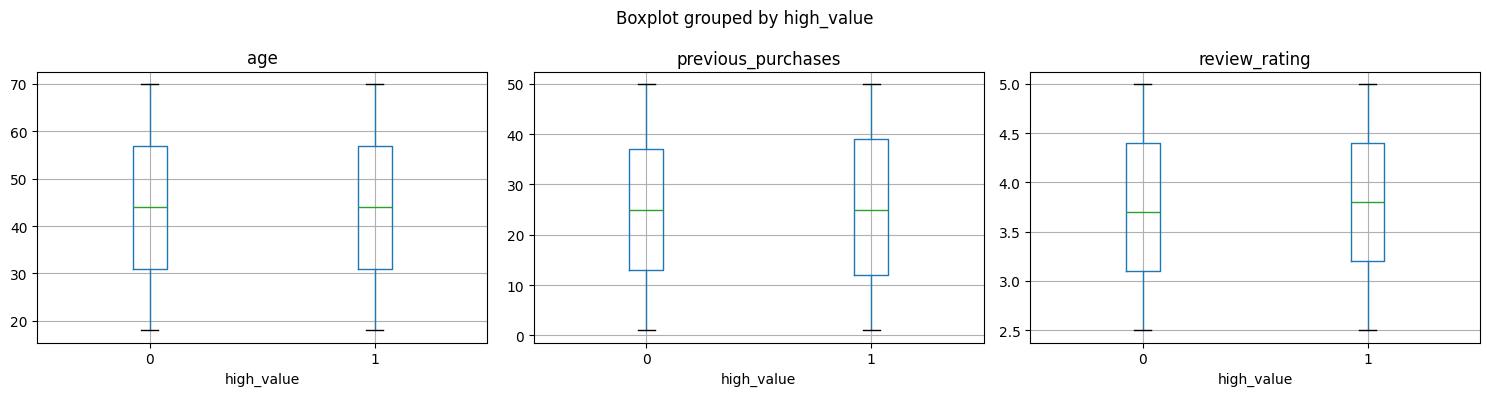

In [43]:
#Plotting box plots
#Calculates the value that separates the top 25% of purchases from the rest
threshold = data['purchase_amount_(usd)'].quantile(0.75)
#Transformed continuous purchase amount data into a binary classification (0,1). With high_value being 1, representing the top 25% of purchases
data['high_value'] = (data['purchase_amount_(usd)'] >= threshold).astype(int)
#Created a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#Showed age distribution split by customer segment
data.boxplot(column='age', by='high_value', ax=axes[0])
#Showed previous purchase history split by customer segment
data.boxplot(column='previous_purchases', by='high_value', ax=axes[1])
#Showed previous review ratings split by customer segment
data.boxplot(column='review_rating', by='high_value', ax=axes[2])
plt.tight_layout()

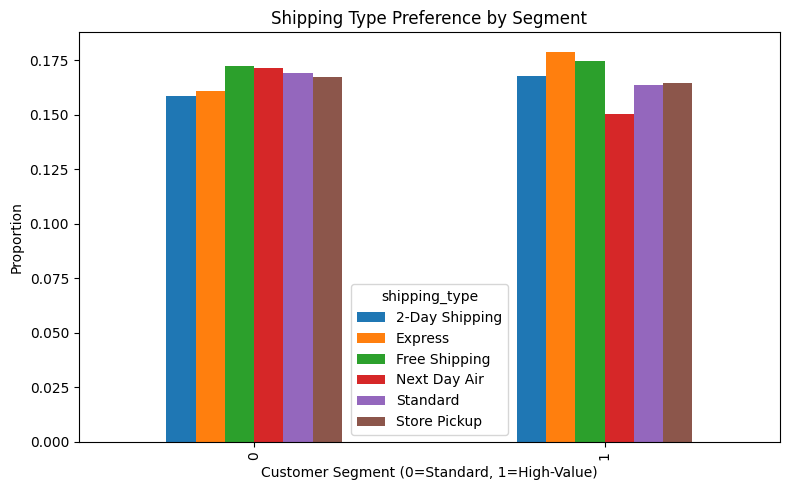

In [44]:
#Created a crosstab and ploted it as a bar chart by focusing on high value purchases and non high value
pd.crosstab(data['high_value'], data['shipping_type'], normalize='index').plot(kind='bar', figsize=(8, 5))
#Create a title
plt.title('Shipping Type Preference by Segment')
#Create y label
plt.ylabel('Proportion')
#Created x label
plt.xlabel('Customer Segment (0=Standard, 1=High-Value)')
#Size adjustment
plt.tight_layout()
#Plotted
plt.show()

High-value customers slightly prefer Express and Free Shipping; standard customers use Next Day Air more

In [45]:
print("Variable names:", data.columns.tolist())

Variable names: ['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases', 'high_value']


Text(0.5, 1.0, 'Purchase Amount Distribution')

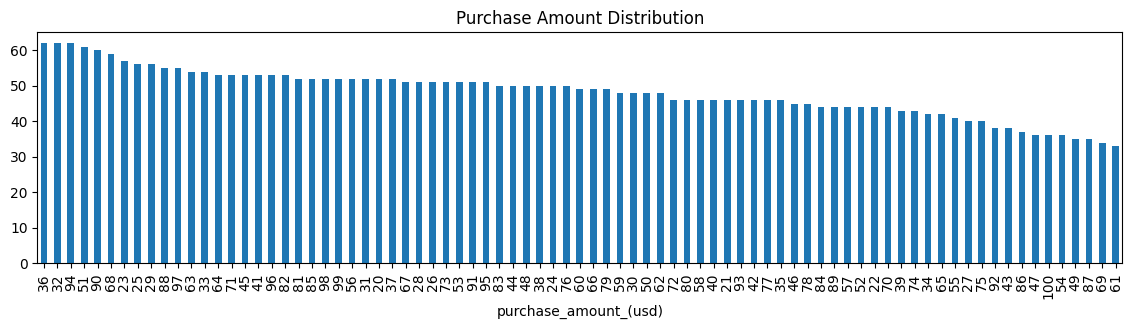

In [46]:
#Ploted Purchase Amount Distribution
plt.figure(figsize=(14,3))
data['purchase_amount_(usd)'].value_counts().plot(kind='bar')
plt.title('Purchase Amount Distribution')

Text(0.5, 1.0, 'Customer Gender Distribution')

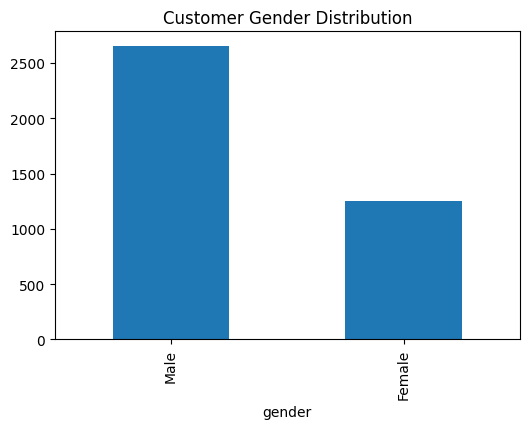

In [47]:
#Ploted Customer Gender Distribution
plt.figure(figsize=(6,4))
data['gender'].value_counts().plot(kind='bar')
plt.title('Customer Gender Distribution')

Category distribution check to assess class balance or dominant groups (uncover relationships, trends, and outliers)


Text(0.5, 1.0, 'Customer Age Distribution')

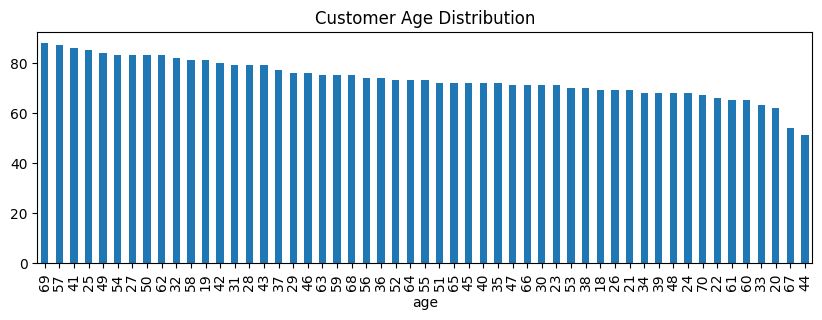

In [48]:
#Ploted Customer Age Distribution
plt.figure(figsize=(10,3))
data['age'].value_counts().plot(kind='bar')
plt.title('Customer Age Distribution')

                      age  review_rating  previous_purchases  high_value
age                 1.000         -0.022               0.040       0.004
review_rating      -0.022          1.000               0.004       0.024
previous_purchases  0.040          0.004               1.000       0.011
high_value          0.004          0.024               0.011       1.000


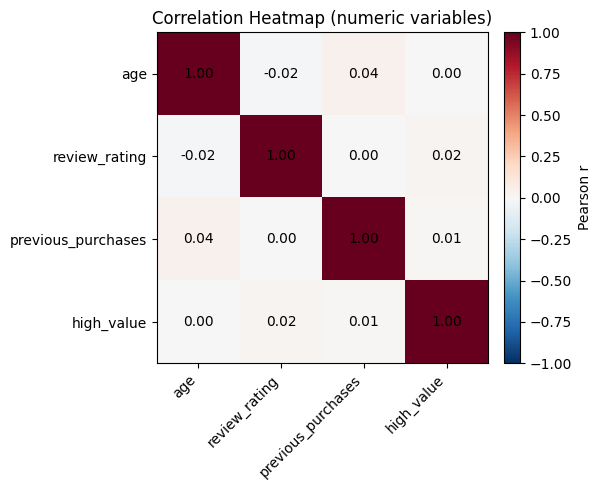

In [49]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

#correlation heatmap
channel_tmp = np.where(
    (data["shipping_type"].astype(str).str.strip().str.lower().str.contains("pickup")) |
    (data["payment_method"].astype(str).str.strip().str.lower().eq("cash")),
    "In-Store", "Online"
)

#use existing high_value; otherwise compute top 25%
if "high_value" in data.columns:
    high_value_tmp = data["high_value"].astype(int).values
else:
    p75 = data["purchase_amount_(usd)"].quantile(0.75)
    high_value_tmp = (data["purchase_amount_(usd)"] >= p75).astype(int).values

corr_df = pd.DataFrame({
    "age": data["age"],
    "review_rating": data["review_rating"],
    "previous_purchases": data["previous_purchases"],
    "high_value": high_value_tmp
})
corr = corr_df.corr()
print(corr.round(3))

#plot heatmap
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr.values, cmap="RdBu_r", norm=norm, interpolation="nearest")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)));   ax.set_yticklabels(corr.index)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Pearson r")
ax.set_title("Correlation Heatmap (numeric variables)")
plt.tight_layout(); plt.show()



The heatmap shows almost zero correlations among the numeric variables and with HighValue (all off-diagonals ≈ –0.02 to 0.04). Age, Review Rating, and Previous Purchases don’t have a strong linear relationship with being a top-quartile spender/ with each other. No single numeric feature explains high-value behavior meaning you’ll get better lift from multi-signal features (recency, frequency, discount usage, channel habits) and/or non-linear models or interactions rather than relying on one metric like age or reviews.

# 3. Data Wrangling & Preprocessing

In [50]:
#Feature Engineering
#Dropping irrelevant columns, encoding categorical variables
data = data.drop(columns=['color','location','item_purchased','customer_id'])
data = pd.get_dummies(data, columns=['gender','category','size','season','subscription_status','discount_applied',
                'promo_code_used', 'payment_method','shipping_type'])
freq_mapping = {
    'Every 3 Months': 'Quarterly',
    'Bi-Weekly': 'Fortnightly'
}
data['frequency_of_purchases'] = data['frequency_of_purchases'].replace(freq_mapping)
freq_order = {
    'Weekly': 6,
    'Fortnightly': 5,
    'Monthly': 4,
    'Quarterly': 3,
    'Annually': 2
}
data['frequency_numeric'] = data['frequency_of_purchases'].map(freq_order)

data = data.drop(columns=['frequency_of_purchases'])

One-Hot Encoding applied to categorical variables. To ensures that 'in-store' purchases are explicitly captured as the 'in-store' category and not conflated with other levels.

In [51]:
#Printed correlation with the encoded variables
correlation_vars = ['review_rating', 'frequency_numeric', 'purchase_amount_(usd)']
correlation_matrix = data[correlation_vars].corr()

print("Correlation with Purchase Amount:")
print(correlation_matrix['purchase_amount_(usd)'].sort_values(ascending=False))

Correlation with Purchase Amount:
purchase_amount_(usd)    1.000000
review_rating            0.030776
frequency_numeric       -0.012473
Name: purchase_amount_(usd), dtype: float64


Gauge linear relationships and potential multicollinearity / transform categorical variables into numeric values so that machine learning algorithms can interpret and learn from them effectively.

# 4. Data Splitting

In [52]:
#Partitioned data 60% training, validation 20% and test 20%
X = data.drop(columns=['purchase_amount_(usd)','high_value'])
threshold = data['purchase_amount_(usd)'].quantile(0.75)  # Top 25% as high-value
y = (data['purchase_amount_(usd)'] >= threshold).astype(int)
# Dropping column purchase_amount_(usd) in X

#Performed split for training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
#Created a StandardScaler object
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

(2340, 36) (2340,) (780, 36) (780,) (780, 36) (780,)


Feature scaling to normalize numerical ranges for model stability.
Train/Test split to estimate generalization performance on unseen data. A predictive model to classify customers by purchase channel or spending level, helping businesses target high-value segments.

# 5. Modeling

In [53]:
#Trained logistic regression model on the training set
logit_full = LogisticRegressionCV(penalty="l2", cv=5,solver='lbfgs',max_iter=500, class_weight='balanced')
#Created cross-validated logistic regression with balanced classes
#Applid L2 regularization (Ridge)
#Applied 5-fold cross-validation
#Used lbfgs to find model coeficients
#Set maximum number of iterations to 500
logit_full.fit(X_train_scaled, y_train)
#Trained logistic regression model on scaled data

LogisticRegressionCV(class_weight='balanced', cv=5, max_iter=500)

In [54]:
#Evaluated which variables impact purchase amount the most
pd.set_option('display.width', 95)
pd.set_option('display.precision',3)
pd.set_option('display.max_columns', 33)
print('intercept ', logit_full.intercept_[0], '\n')
# could use display() to present this cleaner
#Set pandas display options and printed logistic regression intercept
print(pd.DataFrame({'coeff': logit_full.coef_[0]}, index=X.columns).transpose())
pd.reset_option('display.width')
pd.reset_option('display.precision')
pd.reset_option('display.max_columns')
#Displayed model coefficients in DataFrame, reset display options

intercept  -0.006337437215886623 

         age  review_rating  previous_purchases  gender_Female  gender_Male  \
coeff  0.005          0.026               0.007      6.477e-04   -6.477e-04   

       category_Accessories  category_Clothing  category_Footwear  category_Outerwear  \
coeff                -0.005              0.001              0.008              -0.004   

       size_L  size_M  size_S  size_XL  season_Fall  season_Spring  season_Summer  ...  \
coeff  -0.025   0.019  -0.003    0.008         0.03         -0.017         -0.011  ...   

       discount_applied_Yes  promo_code_used_No  promo_code_used_Yes  \
coeff                -0.005               0.005               -0.005   

       payment_method_Bank Transfer  payment_method_Cash  payment_method_Credit Card  \
coeff                        -0.021               -0.032                       0.009   

       payment_method_Debit Card  payment_method_PayPal  payment_method_Venmo  \
coeff                      0.032           

# 6. Validation and Testing

In [55]:
#Calculated predictions and performance metrics for logistic regression using validation set
y_pred = logit_full.predict(X_val_scaled)
logit_full_accuracy = accuracy_score(y_val, y_pred)
logit_full_report = classification_report(y_val, y_pred)
logit_full_precision = precision_score(y_val, y_pred)
logit_full_recall = recall_score(y_val, y_pred)
print("Logistic Regression Accuracy:", logit_full_accuracy)
print("Logistic Regression Precision", logit_full_precision)
print("Logistic Regression Report:", logit_full_report)
print("Logistic Regression Recall:", logit_full_recall)

Logistic Regression Accuracy: 0.5269230769230769
Logistic Regression Precision 0.24507042253521127
Logistic Regression Report:               precision    recall  f1-score   support

           0       0.76      0.55      0.64       592
           1       0.25      0.46      0.32       188

    accuracy                           0.53       780
   macro avg       0.50      0.51      0.48       780
weighted avg       0.64      0.53      0.56       780

Logistic Regression Recall: 0.4627659574468085


The logistic regression model was evaluated using metrics including accuracy, precision, recall, F1-score. These metrics help quantify the model’s ability to correctly identify high-value customers. We used a validation set.

In [56]:
#Printed confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[324 268]
 [101  87]]


Logistic Regression has 268 False Positives and 101 False Negatives


In [57]:
#Now looking into Random Forest Model Classifier
#Calculated predictions and performance metrics for Random Forest using validation set
randomforest = RandomForestClassifier(n_estimators=400,
max_depth=3,
class_weight={0: 1, 1: 3}, # boost weight 3x for high-value customers
random_state = 42)
randomforest.fit(X_train, y_train)
y_pred_randomforest = randomforest.predict(X_val)
randomforest_accuracy = accuracy_score(y_val, y_pred_randomforest)
randomforest_full_report = classification_report(y_val, y_pred_randomforest)
rf_full_precision = precision_score(y_val, y_pred_randomforest)
rf_full_recall = recall_score(y_val, y_pred_randomforest)
print("Random Forest Accuracy:", randomforest_accuracy)
print("Random Forest Report:", randomforest_full_report)
print("RF Precision", rf_full_precision)
print("RF Recall:", rf_full_recall)

Random Forest Accuracy: 0.5628205128205128
Random Forest Report:               precision    recall  f1-score   support

           0       0.77      0.60      0.68       592
           1       0.26      0.45      0.33       188

    accuracy                           0.56       780
   macro avg       0.52      0.52      0.50       780
weighted avg       0.65      0.56      0.59       780

RF Precision 0.2616822429906542
RF Recall: 0.44680851063829785


The Random Forest model was evaluated using metrics including accuracy, precision, recall, F1-score These metrics help quantify the model’s ability to correctly identify high-value customers. We used a validation set to tune model parameters and assessed final performance on the unseen test set.

In [58]:
#Printed Confusion matrix for Random Forest Classifier on validation set
cm = confusion_matrix(y_val, y_pred_randomforest)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[355 237]
 [104  84]]


Random Forest has 237 False Positives and 104 False Negatives

# 7. Results and Final Model Selection

#Random Forest Classifier wins on most metrics
Random Forest achieved an Accuracy of 56.3% on the validation set vs Logistic Regression's 52.7%

Random Forest achieved Precision of 26.2% on the validation set vs Logistic Regression's 24.5%

Random Forest had a slighlty lower Recall of 44.7% compared to Logistic Regression's 46.3%

Random Forest had better overal F1-score 33% vs 32% of Logistic Regression

Finally Random Forest had 31 fewer False Positives compated to Logistic Regression Model


In [59]:
#Picked Random Forest as the model of choice
#Calculated predictions and performance metrics for Random Forest using test set
y_pred_randomforest = randomforest.predict(X_test)
randomforest_accuracy = accuracy_score(y_test, y_pred_randomforest)
randomforest_full_report = classification_report(y_test, y_pred_randomforest)
rf_full_precision = precision_score(y_test, y_pred_randomforest)
rf_full_recall = recall_score(y_test, y_pred_randomforest)
print("Random Forest Accuracy:", randomforest_accuracy)
print("Random Forest Report:", randomforest_full_report)
print("RF Precision", rf_full_precision)
print("RF Recall:", rf_full_recall)

Random Forest Accuracy: 0.5384615384615384
Random Forest Report:               precision    recall  f1-score   support

           0       0.74      0.58      0.65       579
           1       0.26      0.43      0.32       201

    accuracy                           0.54       780
   macro avg       0.50      0.50      0.49       780
weighted avg       0.62      0.54      0.57       780

RF Precision 0.2598187311178248
RF Recall: 0.42786069651741293


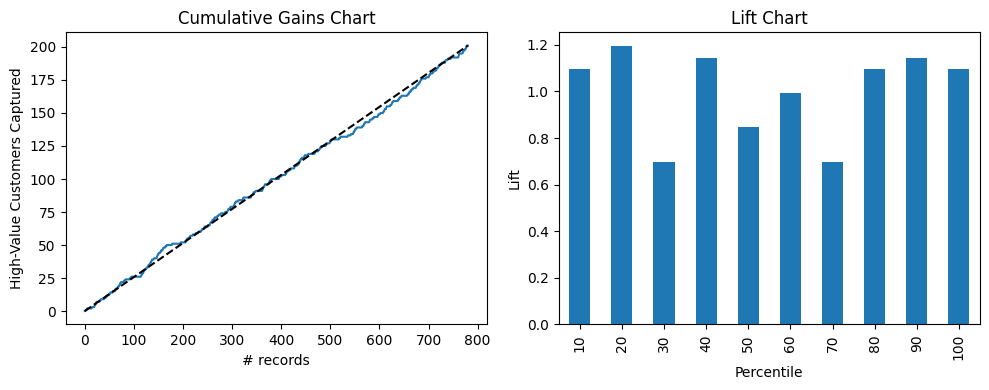

In [60]:
y_pred_proba = randomforest.predict_proba(X_test)[:, 1]
#Got predicted probabilities for positive class only
score_df = pd.DataFrame({'Actual': y_test, 'Probability': y_pred_proba})
#Created DataFrame with actual values and probabilities
score_df_sorted = score_df.sort_values('Probability', ascending=False)
#Sorted DataFrame by probability in descending order
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
#Created subplot figure with 2 columns, specified size.
ax = gainsChart(score_df_sorted['Actual'], ax=axes[0])
#Ploted gains chart using actual values on first subplot
ax.set_ylabel('High-Value Customers Captured')
#Set y-axis label Percentage of High-Value Customers Captured
ax.set_title('Cumulative Gains Chart')
#Set subplot title to Cumulative Gains Chart
ax = liftChart(score_df_sorted['Actual'], ax=axes[1], labelBars=False)
#Plotted lift chart on second subplot without bar labels
ax.set_ylabel('Lift')
#Set y-axis label to Lift
ax.set_title('Lift Chart')
#Set x-axis to Lift Chart
plt.tight_layout()
plt.show()
#Plotted graphs

Visuals to identify customer trends across demographics, loyalty levels, and spending behavior. Highlighting who tends to buy online versus in-store.


In [61]:
#Random Forest Classifier results
score_df_sorted

,Actual,Probability
3742,0,0.549224
2405,1,0.548253
156,0,0.544304
2351,0,0.544100
1965,1,0.543944
...,...,...
2464,1,0.441148
3053,1,0.440140
1027,1,0.437737
1373,0,0.436338


Such models as Logistic Regression with L2 Regularization and Random Forest with 400 trees and max_depth=3 were evaluated. Both Logistic Regression and Random Forest were trained on 60% of the data and compared on 20% validation datasets.

Random Forest was a clear winner as it achieved an Accuracy of 56.3% on the validation set vs Logistic Regression's 52.7%. Achieved Precision of 26.2% on the validation set vs Logistic Regression's 24.5%. Random Forest had better overal F1-score 33% vs 32% of Logistic Regression. Random Forest had 31 fewer False Positives compated to Logistic Regression Model.

Selected Random Forest model was evaluated on a held-out test set,
it achieved an Accuracy of 53.8%, Precision of 26.0 and Recall of 42.8% with overall good generalization and no overfitting.

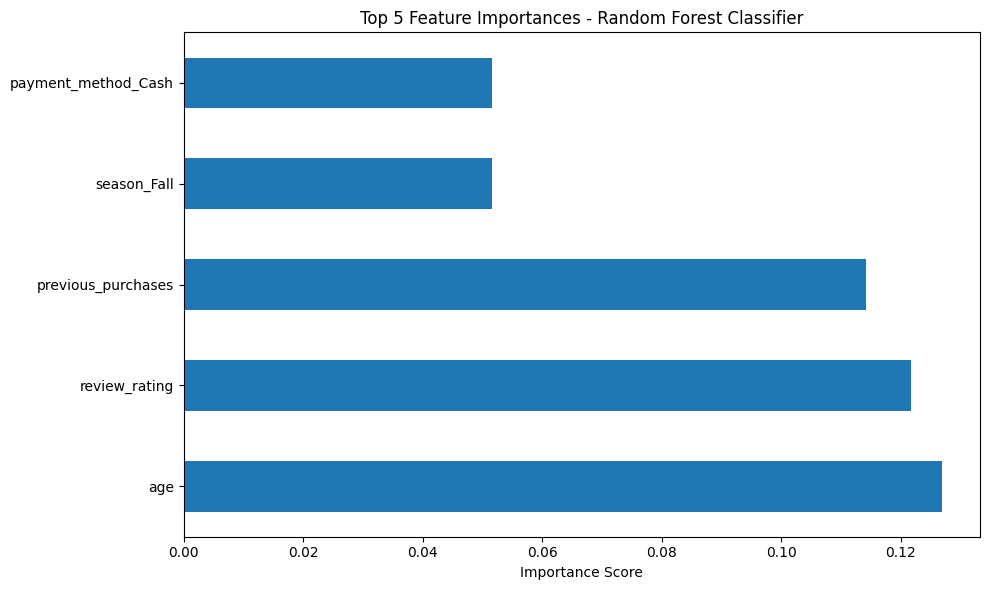

In [62]:
#Plotted top 5 features predictive of high-value customers
plt.figure(figsize=(10, 6))
feature_imp = pd.Series(randomforest.feature_importances_, index=X.columns)
feature_imp.nlargest(5).plot(kind='barh')
plt.title('Top 5 Feature Importances - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Feature importance analysis indicated that demographic features (age) and behavioral features (review rating, previous purchases) were the most influential

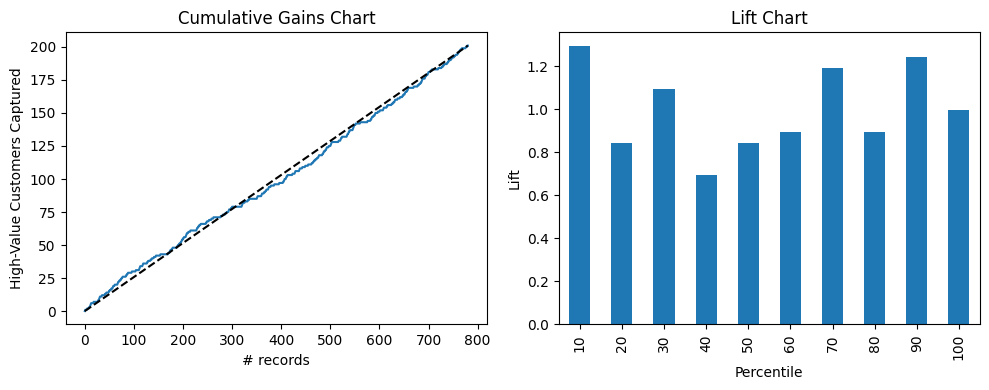

In [63]:
#Logistic Regression Model results
y_pred_proba = logit_full.predict_proba(X_test_scaled)[:, 1]
#Got predicted probabilities for positive class only
score_df = pd.DataFrame({'Actual': y_test, 'Probability': y_pred_proba})
#Created DataFrame with actual values and probabilities
score_df_sorted = score_df.sort_values('Probability', ascending=False)
#Sorted DataFrame by probability in descending order
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
#Created subplot figure with 2 columns, specified size.
ax = gainsChart(score_df_sorted['Actual'], ax=axes[0])
#Ploted gains chart using actual values on first subplot
ax.set_ylabel('High-Value Customers Captured')
#Set y-axis label Percentage of High-Value Customers Captured
ax.set_title('Cumulative Gains Chart')
#Set subplot title to Cumulative Gains Chart
ax = liftChart(score_df_sorted['Actual'], ax=axes[1], labelBars=False)
#Plotted lift chart on second subplot without bar labels
ax.set_ylabel('Lift')
#Set y-axis label to Lift
ax.set_title('Lift Chart')
#Set x-axis to Lift Chart
plt.tight_layout()
plt.show()
#Plotted graphs

This chart pair shows how effectively our model identifies high value customers. The results indicate modest improvement over random guessing  meaning the model captures some meaningful patterns but still has room for improvement. Future iterations can enhance this by refining features such as purchase type, income, and age. Athough logistic regression captures meaningful patterns, additional model complexity or richer data like time-series purchase trends may further improve accuracy.

In [64]:
#Logisitic Regression Probabilities
score_df_sorted

,Actual,Probability
1965,1,0.573248
2915,0,0.565293
3617,0,0.562310
1818,0,0.561685
2405,1,0.561343
...,...,...
1886,1,0.439129
1373,0,0.439083
1377,0,0.437547
1027,1,0.424418


# 8. Discussion and Conclusions


This project demonstrated the use of machine learning techniques to predict high-value customer behavior using demographic and transactional data. While logistic regression model served as interpretable model, the Random Forest model achieved the highest overall performance. The Random Forest model performed the best out of two models with classifying top 25% high value customer with better Accuracy.

Logistic regression captures meaningful patterns as well, additional model complexity or richer data with time-series purchase trends may further improve accuracy.

Both models can guide targeted marketing strategies and loyalty programs. Future work could extend this framework by incorporating social media sentiment and purchase recency.

Conclusion to be continued right at the end of Technical Report

In [65]:
#collapse one-hot columns back to a single label
def collapse_one_hot(df, prefix):
    cols = [c for c in df.columns if c.lower().startswith(prefix.lower() + '_')]
    if not cols:
        return None
    vals = df[cols]
    label_map = {c: c.split('_', 1)[1] for c in cols}   # category_Clothing -> Clothing
    long = vals.reset_index().melt(id_vars='index', var_name='col', value_name='val')
    long = long[long['val'] == 1]
    picked = long.sort_values(['index','col']).drop_duplicates('index')\
                 .set_index('index')['col'].map(label_map)
    return picked.reindex(df.index)

#get binary from one-hots or fallback text
def binary_from_onehot_or_text(df, yes_col, no_col=None, text_col=None):
    if yes_col in df.columns:
        return df[yes_col].astype(int)
    if text_col and text_col in df.columns:
        return df[text_col].astype(str).str.strip().str.lower().isin(['yes','y','true','1']).astype(int)
    if no_col in df.columns:
        return (1 - df[no_col].astype(int)).clip(0,1)
    return pd.Series(np.nan, index=df.index)


#coerce numerics used later
for c in ['purchase_amount_(usd)', 'age', 'review_rating', 'previous_purchases', 'frequency_numeric']:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors='coerce')

#channel from shipping_type 'pickup' - In-Store; else Online
if 'shipping_type' in data.columns:
    st = data['shipping_type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup'), 'In-Store', 'Online')
else:
    data['Channel'] = 'Online'  # fallback

#age cohorts
data['Age Cohort'] = pd.cut(
    data['age'],
    bins=[0,24,34,44,54,64,np.inf],
    labels=['<25','25-34','35-44','45-54','55-64','65+'],
    include_lowest=True
)

#review buckets
data['Review Bucket'] = pd.cut(
    data['review_rating'],
    bins=[-np.inf,3,4,np.inf],
    labels=['Low (<3)','Mid (3-4]','High (>4)']
)

#binary flags (prefer one-hot form)
data['Is Subscriber']   = binary_from_onehot_or_text(data, 'subscription_status_Yes', 'subscription_status_No', 'subscription_status')
data['Discount Flag']   = binary_from_onehot_or_text(data, 'discount_applied_Yes',    'discount_applied_No',    'discount_applied')
data['Promo Code Flag'] = binary_from_onehot_or_text(data, 'promo_code_used_Yes',     'promo_code_used_No',     'promo_code_used')

#category and Payment method reconstructed from one-hots
cat_series = collapse_one_hot(data, 'category')
data['Category'] = cat_series if cat_series is not None else data.get('Category')

pay_series = collapse_one_hot(data, 'payment_method')
data['Payment Method'] = pay_series if pay_series is not None else data.get('Payment Method')


In [66]:
#Edit previous code for appropriate Channel from shipping_type:
#'pickup' → In-Store; all else → Online
if 'shipping_type' in data.columns:
    st = data['shipping_type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup', na=False), 'In-Store', 'Online')

#If lowercase version doesn't exist but one-hot or title-case does
elif 'Shipping Type' in data.columns:
    st = data['Shipping Type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup', na=False), 'In-Store', 'Online')

#Fallback using one-hot encoded flag if text column isn't found
elif 'shipping_type_Store Pickup' in data.columns:
    data['Channel'] = np.where(data['shipping_type_Store Pickup'] == True, 'In-Store', 'Online')

else:
    data['Channel'] = 'Online'  # final fallback if none found

print("Channel value counts:\n", data['Channel'].value_counts())

Channel value counts:
 Channel
Online      3250
In-Store     650
Name: count, dtype: int64



Age x Channel (Counts)
 Channel     In-Store  Online
Age Cohort                  
<25               82     404
25-34            124     631
35-44            136     593
45-54            132     620
55-64            115     636
65+               61     366

Age x Channel (Row %)
 Channel     In-Store  Online
Age Cohort                  
<25             16.9    83.1
25-34           16.4    83.6
35-44           18.7    81.3
45-54           17.6    82.4
55-64           15.3    84.7
65+             14.3    85.7


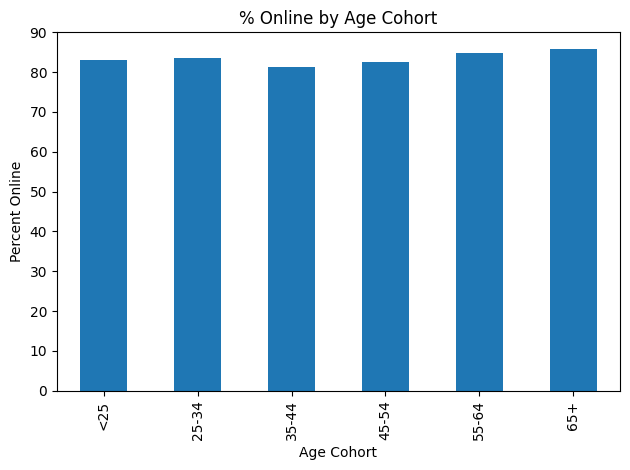

In [67]:
#Age × Channel (counts & row % + chart)
age_ct = pd.crosstab(data['Age Cohort'], data['Channel']) #contigency table
age_rowpct = (age_ct.div(age_ct.sum(1), 0) * 100).round(1) #converting percentages in each row
print("\nAge x Channel (Counts)\n", age_ct)
print("\nAge x Channel (Row %)\n", age_rowpct)

plt.figure()
((age_ct.get('Online', 0) / age_ct.sum(1)) * 100).plot(kind='bar')
plt.title('% Online by Age Cohort'); plt.xlabel('Age Cohort'); plt.ylabel('Percent Online')
plt.tight_layout(); plt.show()



Online dominates across all ages more than 80 % of purchases are online regardless of age.
Older cohorts (55–65+) are slightly more online-active than younger groups, which is interesting it contradicts the usual assumption that older shoppers favor stores.
Younger cohorts (<25, 25–34) still lean heavily online, but they’re a bit more likely than seniors to use in-store channels, possibly due to store proximity or social shopping habits.


Category x Channel (Counts)
 Channel      In-Store  Online
Category                     
Accessories       217    1023
Clothing          282    1455
Footwear           98     501
Outerwear          53     271

Category Share within Channel (%)
 Channel      In-Store  Online
Accessories       NaN     NaN
Clothing          NaN     NaN
Footwear          NaN     NaN
In-Store          NaN     NaN
Online            NaN     NaN
Outerwear         NaN     NaN


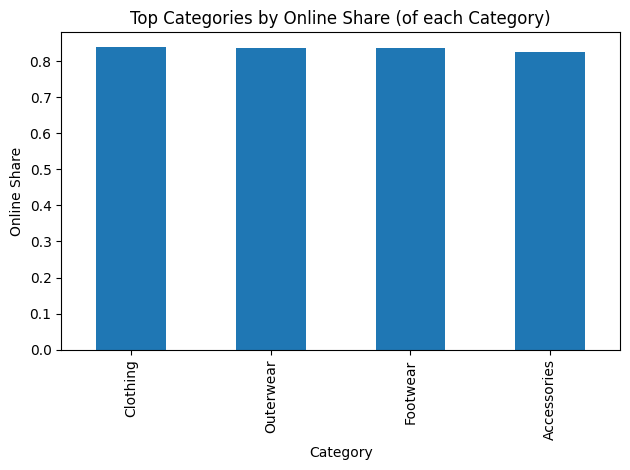

In [68]:
#Category mix by Channel)
cat_ct = pd.crosstab(data['Category'], data['Channel']) #count table of how many purchases were made per category × channel.
cat_share = (cat_ct.div(cat_ct.sum(0), 0) * 100).round(1) #what % of each channel comes from each category
print("\nCategory x Channel (Counts)\n", cat_ct)
print("\nCategory Share within Channel (%)\n", cat_share)

top_online_share = (cat_ct.get('Online', 0) / cat_ct.sum(1)).fillna(0).sort_values(ascending=False).head(8) #Calculates, for each category, % of its sales that happen Online
plt.figure()
top_online_share.plot(kind='bar')
plt.title('Top Categories by Online Share (of each Category)')
plt.xlabel('Category'); plt.ylabel('Online Share')
plt.tight_layout(); plt.show()


Clothing, Footwear, and Accessories are all strongly online-driven (about 4 out of 5 purchases happen online) Outerwear is slightly lower, but still mostly online. There’s no single category that stands out as an in-store leader even items that people often try on (like footwear) are largely purchased online.

/tmp/ipython-input-2932850840.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_grp = data.groupby('Review Bucket').agg(



Review Bucket vs Behavior
                avg_purchase  avg_prev_purchases     n
Review Bucket                                        
Low (<3)              58.94               25.19   847
Mid (3-4]             59.29               25.44  1590
High (>4)             60.75               25.35  1463

Subscription x Channel vs Behavior
    Is Subscriber   Channel  avg_purchase  avg_prev_purchases     n
0              0  In-Store         60.80               25.10   460
1              0    Online         59.69               25.08  2387
2              1  In-Store         57.71               24.08   190
3              1    Online         59.88               26.53   863


<Figure size 640x480 with 0 Axes>

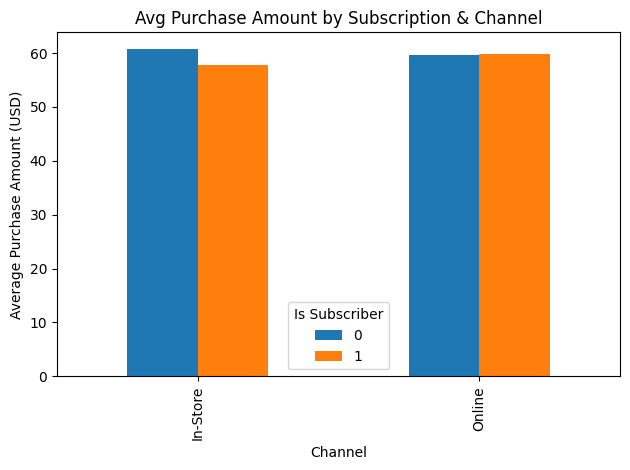

In [69]:
#Review buckets vs spend & repeat
review_grp = data.groupby('Review Bucket').agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    avg_prev_purchases=('previous_purchases', 'mean'),
    n=('age', 'count')
).round(2)
print("\nReview Bucket vs Behavior\n", review_grp)

#subscriber vs non-subscriber by channel
sub_grp = data.groupby(['Is Subscriber', 'Channel']).agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    avg_prev_purchases=('previous_purchases', 'mean'),
    n=('age', 'count')
).round(2).reset_index()
print("\nSubscription x Channel vs Behavior\n", sub_grp)

#chart
sub_pivot = sub_grp.pivot(index='Channel', columns='Is Subscriber', values='avg_purchase')
plt.figure()
sub_pivot.plot(kind='bar')
plt.title('Avg Purchase Amount by Subscription & Channel')
plt.xlabel('Channel'); plt.ylabel('Average Purchase Amount (USD)')
plt.tight_layout(); plt.show()


Subscribers and non-subscribers spend about the same amount per purchase, showing that subscription status doesn’t strongly affect how much customers spend. In-store non-subscribers make slightly higher-value purchases, while online subscribers buy more frequently but with similar order values. Overall, subscriptions appear to drive loyalty and repeat behavior rather than bigger single-purchase amounts.

In [70]:
#payment methos
pay_channel = pd.crosstab(data['Payment Method'], data['Channel'])
pay_age = pd.crosstab(data['Payment Method'], data['Age Cohort'])
print("\nPayment Method x Channel (Counts)\n", pay_channel)
print("\nPayment Method x Age Cohort (Counts)\n", pay_age)



Payment Method x Channel (Counts)
 Channel               In-Store  Online
Payment Method                        
method_Bank Transfer       112     500
method_Cash                119     551
method_Credit Card         104     567
method_Debit Card          105     531
method_PayPal              103     574
method_Venmo               107     527

Payment Method x Age Cohort (Counts)
 Age Cohort            <25  25-34  35-44  45-54  55-64  65+
Payment Method                                            
method_Bank Transfer   83    123    104    121    101   80
method_Cash            93    129    110    127    135   76
method_Credit Card     81    129    128    116    135   82
method_Debit Card      75    118    133    124    120   66
method_PayPal          77    124    132    148    136   60
method_Venmo           77    132    122    116    124   63



Promotion Effect (Discount vs No Discount)
                avg_purchase     n
Discount Flag                    
0                     60.13  2223
1                     59.28  1677

Promo Code Usage x Channel (Counts)
 Channel          In-Store  Online
Promo Code Flag                  
0                     365    1858
1                     285    1392

Promo Code Usage Rate within Channel (%)
 Channel   In-Store  Online
0              NaN     NaN
1              NaN     NaN
In-Store       NaN     NaN
Online         NaN     NaN


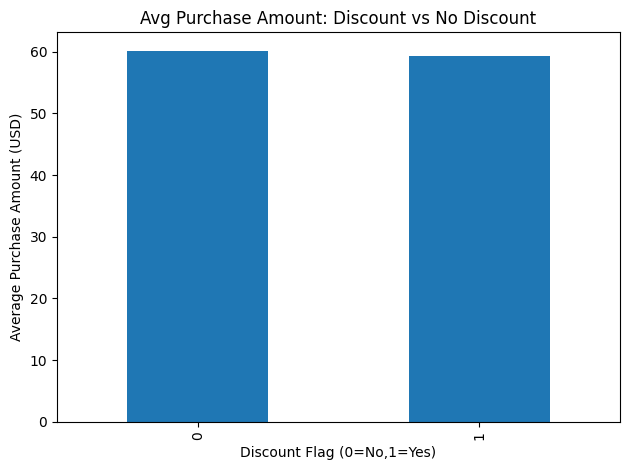

In [71]:
#Average spend with vs. without discount (Discount Flag is 1 = discount applied, 0 = no discount.)
promo_effect = data.groupby('Discount Flag').agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    n=('age', 'count')
).round(2)
print("\nPromotion Effect (Discount vs No Discount)\n", promo_effect)

promo_code_ct = pd.crosstab(data['Promo Code Flag'], data['Channel']) #Promo Code Flag = 1 if promo used, 0 otherwise.
promo_code_rate = (promo_code_ct.div(promo_code_ct.sum(0), 0) * 100).round(1)
print("\nPromo Code Usage x Channel (Counts)\n", promo_code_ct)
print("\nPromo Code Usage Rate within Channel (%)\n", promo_code_rate)

plt.figure()
promo_effect['avg_purchase'].plot(kind='bar')
plt.title('Avg Purchase Amount: Discount vs No Discount')
plt.xlabel('Discount Flag (0=No,1=Yes)'); plt.ylabel('Average Purchase Amount (USD)')
plt.tight_layout(); plt.show()


Discounts help attract buyers but don’t significantly increase spending per order. In other words, promo codes likely drive conversions rather than higher-value purchases, so they’re best used for volume growth or customer acquisition, not for boosting order size

In [72]:
from scipy.stats import chi2_contingency, ttest_ind


#Chi-Square Tests (categorical relationships)

def chi_square_test(table, name="Chi-Square Test"):
    chi2, p, dof, exp = chi2_contingency(table)
    print(f"\n{name}")
    print("Chi-square:", round(chi2, 3), " | dof:", dof, " | p-value:", round(p, 4))
    return p

#Age Cohort × Channel
chi_square_test(pd.crosstab(data['Age Cohort'], data['Channel']), "Age Cohort × Channel")

#Category × Channel
chi_square_test(pd.crosstab(data['Category'], data['Channel']), "Category × Channel")

#Promo Code × Channel
chi_square_test(pd.crosstab(data['Promo Code Flag'], data['Channel']), "Promo Code × Channel")


#t-tests (mean spend differences)
def t_test_groups(series, group, g1=1, g0=0, label="Group"):
    """Run t-test comparing spend across two groups (1 vs 0)."""
    s1 = series[group==g1]
    s0 = series[group==g0]
    t, p = ttest_ind(s1, s0, equal_var=False, nan_policy='omit')
    print(f"\n{label}: mean spend {g1}={s1.mean():.2f}, {g0}={s0.mean():.2f}")
    print(f"t={t:.3f}, p={p:.4f}, N={len(s1)+len(s0)}")
    return p

#Subscribers vs Non
t_test_groups(data['purchase_amount_(usd)'], data['Is Subscriber'], label="Subscribers vs Non")

#Discount vs No Discount
t_test_groups(data['purchase_amount_(usd)'], data['Discount Flag'], label="Discount vs No Discount")

#Promo Code vs No Promo Code
t_test_groups(data['purchase_amount_(usd)'], data['Promo Code Flag'], label="Promo Code vs No Promo Code")

#Age Cohort × Channel: Avg purchase
age_channel_table = data.groupby(['Age Cohort','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Age Cohort × Channel\n", age_channel_table.round(2))

#Category × Channel: Avg purchase
cat_channel_table = data.groupby(['Category','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Category × Channel\n", cat_channel_table.round(2))

#Discount × Channel
disc_channel_table = data.groupby(['Discount Flag','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Discount Flag × Channel\n", disc_channel_table.round(2))

#Subscribers × Review Bucket
sub_review_table = data.groupby(['Is Subscriber','Review Bucket'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Subscription × Review Bucket\n", sub_review_table.round(2))



Age Cohort × Channel
Chi-square: 5.283  | dof: 5  | p-value: 0.3824

Category × Channel
Chi-square: 0.916  | dof: 3  | p-value: 0.8216

Promo Code × Channel
Chi-square: 0.188  | dof: 1  | p-value: 0.6643

Subscribers vs Non: mean spend 1=59.49, 0=59.87
t=-0.440, p=0.6603, N=3900

Discount vs No Discount: mean spend 1=59.28, 0=60.13
t=-1.112, p=0.2661, N=3900

Promo Code vs No Promo Code: mean spend 1=59.28, 0=60.13
t=-1.112, p=0.2661, N=3900

Avg Purchase Amount by Age Cohort × Channel
 Channel     In-Store  Online
Age Cohort                  
<25            59.17   60.41
25-34          57.37   60.68
35-44          61.85   59.11
45-54          60.45   60.31
55-64          60.96   58.31
65+            58.43   59.92

Avg Purchase Amount by Category × Channel
 Channel      In-Store  Online
Category                     
Accessories     59.52   59.91
Clothing        58.24   60.37
Footwear        61.67   59.98
Outerwear       66.94   55.26

Avg Purchase Amount by Discount Flag × Channel
 Ch

/tmp/ipython-input-2301846155.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_channel_table = data.groupby(['Age Cohort','Channel'])['purchase_amount_(usd)'].mean().unstack()
/tmp/ipython-input-2301846155.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_review_table = data.groupby(['Is Subscriber','Review Bucket'])['purchase_amount_(usd)'].mean().unstack()


Statistical tests show no significant differences in spending or channel preference across customer groups. Age, category, subscription, and discount use don’t meaningfully affect how much customers spend or where they shop.

=== Total Spend and Percent Share by Channel ===
    Channel  purchase_amount_(usd)  Percent of Total
1    Online                 194150         83.297223
0  In-Store                  38931         16.702777


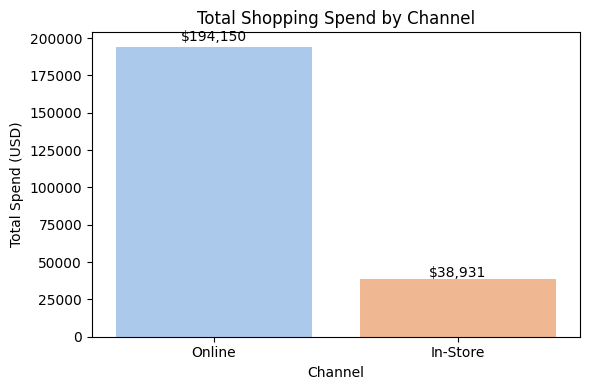

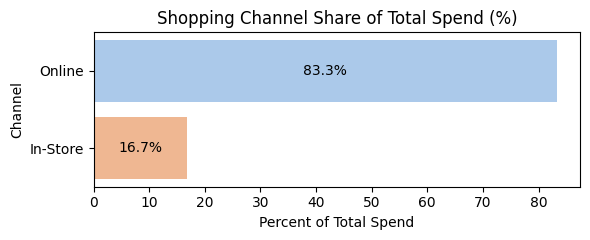

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Aggregate total spend per channel
channel_spend = (
    data.groupby('Channel')['purchase_amount_(usd)']
        .sum()
        .reset_index()
        .sort_values('purchase_amount_(usd)', ascending=False)
)

#Calculate each channel’s share of total
channel_spend['Percent of Total'] = (
    channel_spend['purchase_amount_(usd)'] /
    channel_spend['purchase_amount_(usd)'].sum() * 100
)

print("=== Total Spend and Percent Share by Channel ===")
print(channel_spend)

#Column Chart
plt.figure(figsize=(6,4))
sns.barplot(
    x='Channel',
    y='purchase_amount_(usd)',
    data=channel_spend,
    hue='Channel',          # fixes seaborn palette warning
    palette='pastel',
    legend=False
)

#value labels
for i, val in enumerate(channel_spend['purchase_amount_(usd)']):
    plt.text(i, val + (val * 0.02), f"${val:,.0f}", ha='center', fontsize=10)

plt.title('Total Shopping Spend by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Spend (USD)')
plt.tight_layout()
plt.show()

#Horizontal Percentage Bar Chart
plt.figure(figsize=(6,2.5))
sns.barplot(
    y='Channel',
    x='Percent of Total',
    data=channel_spend,
    palette='pastel',
    hue='Channel',
    legend=False
)

#percentage labels
for i, val in enumerate(channel_spend['Percent of Total']):
    plt.text(val / 2, i, f"{val:.1f}%", color='black', ha='center', va='center', fontsize=10)

plt.title('Shopping Channel Share of Total Spend (%)')
plt.xlabel('Percent of Total Spend')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()


Total spending is heavily concentrated online, with about 83% of total sales coming from online purchases and only 17% from in-store. This confirms that the online channel dominates both in transaction volume and revenue contribution, highlighting the importance of prioritizing digital marketing, online customer experience, and e-commerce optimization.

In [74]:
import re
import numpy as np

#one-hot column for Store Pickup no matter how it's cased/spaced
def find_store_pickup_flag(df):
    for c in df.columns:
        norm = re.sub(r'[^a-z0-9]', '', c.lower())
        #match shipping_type_store_pickup / store_pickup / shippingtypestorepickup
        if norm.endswith('shippingtypestorepickup') or norm.endswith('storepickup'):
            return c
    return None

flag_col = find_store_pickup_flag(data)
if flag_col is None:

    flag_col = 'shipping_type_Store Pickup' if 'shipping_type_Store Pickup' in data.columns else None

if flag_col is None:
    raise KeyError("Couldn't find a Store Pickup one-hot column. Print(data.columns) to inspect.")

#channel from the one-hot column (True => In-Store, else Online)
data['Channel'] = np.where(data[flag_col].astype(bool), 'In-Store', 'Online')

print("Channel counts (from one-hot):")
print(data['Channel'].value_counts(dropna=False))



Channel counts (from one-hot):
Channel
Online      3250
In-Store     650
Name: count, dtype: int64


In [75]:
#use spend column
spend_col = 'purchase_amount_(usd)' if 'purchase_amount_(usd)' in data.columns else 'Purchase Amount (USD)'
data[spend_col] = pd.to_numeric(data[spend_col], errors='coerce').fillna(0)

#category x Channel totals
cat_spend = (
    data.groupby(['Category', 'Channel'], as_index=False)[spend_col]
        .sum()
        .rename(columns={spend_col: 'Total Spend (USD)'})
)

#top 5 per channel
top_online = (cat_spend.query("Channel == 'Online'")
              .sort_values('Total Spend (USD)', ascending=False).head(5))
top_store  = (cat_spend.query("Channel == 'In-Store'")
              .sort_values('Total Spend (USD)', ascending=False).head(5))

print("\nTop Online Categories by Spend\n", top_online)
print("\nTop In-Store Categories by Spend\n", top_store if not top_store.empty else "No In-Store rows / (Store Pickup) found")



Top Online Categories by Spend
       Category Channel  Total Spend (USD)
3     Clothing  Online              87840
1  Accessories  Online              61285
5     Footwear  Online              30049
7    Outerwear  Online              14976

Top In-Store Categories by Spend
       Category   Channel  Total Spend (USD)
2     Clothing  In-Store              16424
0  Accessories  In-Store              12915
4     Footwear  In-Store               6044
6    Outerwear  In-Store               3548


Clothing and accessories are the top revenue drivers for both online and in-store channels. This reinforces that online dominates total revenue and that fashion-related categories contribute the most to overall sales across both channels.

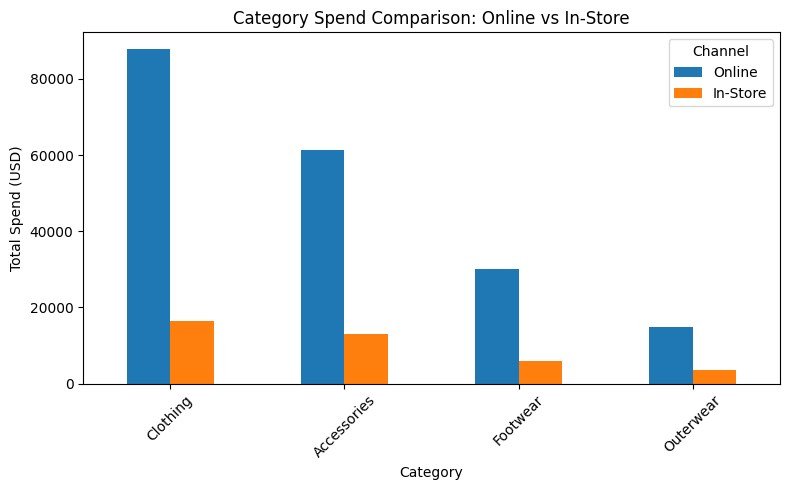

In [76]:
#Online vs In-Store Spend per Category
#Pivot category spend into side-by-side format
pivot_spend = (
    cat_spend.pivot(index='Category', columns='Channel', values='Total Spend (USD)')
              .fillna(0)
              .sort_values('Online', ascending=False)
)

#bar chart
pivot_spend[['Online', 'In-Store']].plot(kind='bar', figsize=(8,5))
plt.title('Category Spend Comparison: Online vs In-Store')
plt.xlabel('Category')
plt.ylabel('Total Spend (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average spend per transaction by channel:
     Channel  Average Spend (USD)
0  In-Store            59.893846
1    Online            59.738462


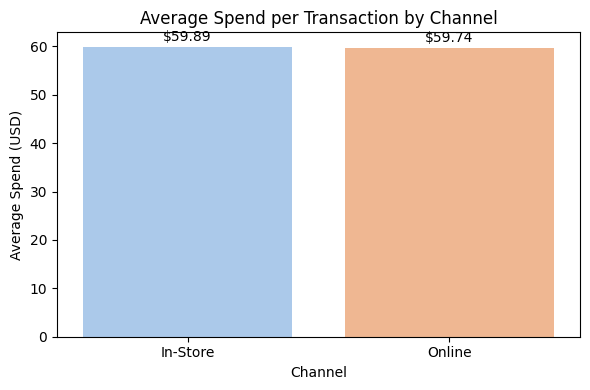

In [77]:
#Average spend per transaction $
avg_spend = (
    data.groupby('Channel')['purchase_amount_(usd)']
        .mean()
        .reset_index()
        .rename(columns={'purchase_amount_(usd)': 'Average Spend (USD)'})
        .sort_values('Average Spend (USD)', ascending=False)
)

print("Average spend per transaction by channel:\n", avg_spend)

#visualize
plt.figure(figsize=(6,4))
sns.barplot(
    x='Channel',
    y='Average Spend (USD)',
    data=avg_spend,
    hue='Channel',
    palette='pastel',
    legend=False
)

#Add value labels
for i, val in enumerate(avg_spend['Average Spend (USD)']):
    plt.text(i, val + (val * 0.02), f"${val:,.2f}", ha='center', fontsize=10)

plt.title('Average Spend per Transaction by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Spend (USD)')
plt.tight_layout()
plt.show()


The average spend per transaction is nearly identical across channels (in store/ online) about 59.89USD instore and 59.74USD online. This shows that while total revenue is much higher online (due to more transactions), the typical purchase amount per customer is consistent between online and in-store shoppers.

# 8. Final Conclusion Continued

Online shopping drives 83% of revenue, but channel choice doesn't predict who spends more. In fact, such features as age, category, subscription status do not show significant differences in spending behavior. Review ratings and purchase history have some predictive value, but it's weak.

The Random Forest model hit 54% accuracy with 26% precision on the test. That precision rate means we're wrong about high-value customers three-quarters of the time. The model works, but barely.

Our model won't reliably identify high spenders. With 26% precision, targeting predicted "high-value" customers would waste resources on misclassified buyers. For dataset to be richer we need information on recency of the purchase, how often customers return.

In [78]:
!jupyter nbconvert --to html /content/ADS505_Group_Project_.ipynb

[NbConvertApp] WARNING | pattern '/content/ADS505_Group_Project_.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=